In [1]:
!pip install tensorflow torch matplotlib tensorflow-gan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.1/367.1 kB 27.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from scipy.linalg import sqrtm

In [3]:
# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
# Configs
latent_dim = 256
image_size = 64
batch_size = 64
num_epochs = 200
learning_rate = 1e-3
data_dir = "/content/drive/MyDrive/Yelp_Balance_Dataset/balanced_photos"
json_path = "/content/drive/MyDrive/Yelp_Balance_Dataset/balanced_photos.json"

In [6]:
# Load images
def load_images(df, data_dir, limit=20000):
    images, labels = [], []
    count = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Loading Images"):
        if count >= limit:
            break
        img_path = os.path.join(data_dir, f"{row['photo_id']}.jpg")
        if os.path.exists(img_path):
            try:
                img = Image.open(img_path).convert("RGB").resize((image_size, image_size))
                img = np.array(img).astype(np.float32) / 255.0
                images.append(img.transpose(2, 0, 1))  # Channel-first
                labels.append(row['label'])
                count += 1
            except:
                continue
    return np.array(images, dtype=np.float32), np.array(labels)

In [7]:
# Load metadata
df_balanced_metadata = pd.read_json(json_path, lines=True)
print("Balanced dataset size:", len(df_balanced_metadata))

Balanced dataset size: 8390


In [8]:
# Load and preprocess data
# images, labels = load_images(df_balanced_metadata, data_dir, limit=2000)
images, labels = load_images(df_balanced_metadata, data_dir)

Loading Images: 100%|██████████| 8390/8390 [1:55:39<00:00,  1.21it/s]


In [9]:
train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

In [10]:
train_ds = DataLoader(TensorDataset(torch.tensor(train_imgs)), batch_size=batch_size, shuffle=True)
test_ds = torch.tensor(test_imgs)

In [11]:
# VAE encoder
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128 * 8 * 8, 256)
        self.fc_mean = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), negative_slope=0.2)
        x = F.leaky_relu(self.conv2(x), negative_slope=0.2)
        x = F.leaky_relu(self.conv3(x), negative_slope=0.2)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc(x))
        return self.fc_mean(x), self.fc_logvar(x)

In [12]:
# VAE decoder
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 128 * 8 * 8)
        self.deconv1 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.deconv2 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.deconv3 = nn.ConvTranspose2d(32, 3, 4, 2, 1)

    def forward(self, z):
        x = F.leaky_relu(self.fc(z), 0.2)
        x = x.view(-1, 128, 8, 8)
        x = F.leaky_relu(self.deconv1(x), 0.2)
        x = F.leaky_relu(self.deconv2(x), 0.2)
        return torch.sigmoid(self.deconv3(x))

In [13]:
# VAE
class VAE(nn.Module):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

In [14]:
# Loss
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

In [15]:
# Initialize
encoder = Encoder().to(device)
decoder = Decoder().to(device)
vae = VAE(encoder, decoder).to(device)

# Weight init
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.xavier_normal_(m.weight)

vae.apply(init_weights)

optimizer = optim.Adam(vae.parameters(), lr=learning_rate)

In [28]:
# Training loop
vae.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch, in train_ds:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = vae(batch)
        loss = vae_loss(recon_batch, batch, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_ds.dataset):.4f}")

Epoch 1, Loss: 6550.2729
Epoch 2, Loss: 6549.9027
Epoch 3, Loss: 6549.5406
Epoch 4, Loss: 6548.1787
Epoch 5, Loss: 6549.8965
Epoch 6, Loss: 6548.1931
Epoch 7, Loss: 6550.1790
Epoch 8, Loss: 6547.9982
Epoch 9, Loss: 6549.3526
Epoch 10, Loss: 6548.7897
Epoch 11, Loss: 6548.0609
Epoch 12, Loss: 6548.3582
Epoch 13, Loss: 6548.8332
Epoch 14, Loss: 6547.3016
Epoch 15, Loss: 6547.2393
Epoch 16, Loss: 6546.7606
Epoch 17, Loss: 6547.9008
Epoch 18, Loss: 6545.8121
Epoch 19, Loss: 6546.8349
Epoch 20, Loss: 6547.6574
Epoch 21, Loss: 6545.3822
Epoch 22, Loss: 6544.5087
Epoch 23, Loss: 6545.4999
Epoch 24, Loss: 6546.4764
Epoch 25, Loss: 6546.3753
Epoch 26, Loss: 6545.1145
Epoch 27, Loss: 6544.9944
Epoch 28, Loss: 6545.7151
Epoch 29, Loss: 6545.2235
Epoch 30, Loss: 6544.2425
Epoch 31, Loss: 6543.9555
Epoch 32, Loss: 6544.9199
Epoch 33, Loss: 6543.8960
Epoch 34, Loss: 6543.5393
Epoch 35, Loss: 6544.5049
Epoch 36, Loss: 6544.7364
Epoch 37, Loss: 6543.1626
Epoch 38, Loss: 6542.5815
Epoch 39, Loss: 6543.

In [32]:
# Generate images
vae.eval()
z = torch.randn(500, latent_dim).to(device)
with torch.no_grad():
    generated_imgs = decoder(z).cpu()

In [33]:
# Compute Inception Score and FID
import torchvision.transforms as T
from torchvision.models.inception import inception_v3

In [34]:
def get_inception_activations(images, model):
    model.eval()
    activations = []
    transform = T.Compose([
        T.Resize((299, 299)),
        T.Normalize((0.5,), (0.5,))
    ])
    for img in images:
        img = transform(img)
        with torch.no_grad():
            act = model(img.unsqueeze(0).to(device))
            activations.append(act.squeeze().cpu().numpy())
    return np.array(activations)

In [35]:
def inception_score(images, model, splits=10):
    model.eval()
    preds = []
    softmax = nn.Softmax(dim=1)
    transform = T.Compose([
        T.Resize((299, 299)),
        T.Normalize((0.5,), (0.5,))
    ])
    for img in images:
        img = transform(img)
        with torch.no_grad():
            pred = softmax(model(img.unsqueeze(0).to(device)))
            preds.append(pred.cpu().numpy())
    preds = np.concatenate(preds, axis=0)
    scores = []
    split_size = preds.shape[0] // splits
    for i in range(splits):
        part = preds[i * split_size: (i+1) * split_size]
        py = np.mean(part, axis=0)
        scores.append(np.exp(np.sum(part * (np.log(part + 1e-10) - np.log(py + 1e-10)), axis=1).mean()))
    return np.mean(scores), np.std(scores)

In [36]:
def calculate_fid(act1, act2):
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)

In [37]:
# Inception model for scoring
inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
inception_model.fc = nn.Identity()  # Use

In [38]:
# Get activations
real_acts = get_inception_activations(torch.tensor(test_imgs), inception_model)
gen_acts = get_inception_activations(generated_imgs, inception_model)

In [39]:
# Scores
mean_is, std_is = inception_score(generated_imgs, inception_model)
fid_score = calculate_fid(real_acts, gen_acts)

In [40]:
print(f"Inception Score: {mean_is:.4f} ± {std_is:.4f}")
print(f"FID Score: {fid_score:.4f}")

Inception Score: 1.0550 ± 0.0063
FID Score: 208.9872


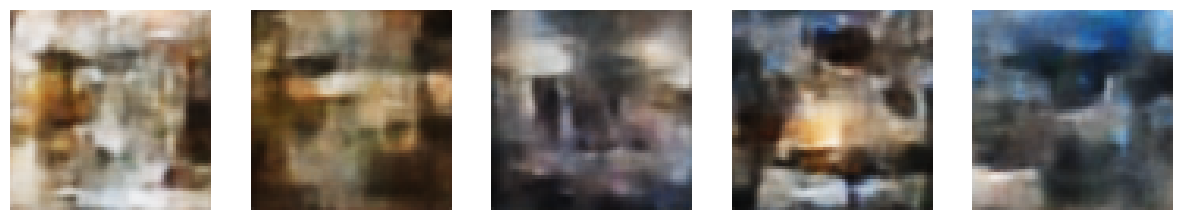

In [41]:
# Plot results
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axs[i].imshow(generated_imgs[i].permute(1, 2, 0))
    axs[i].axis('off')
plt.show()